# Module 5 — Revenue Forecasting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json
import os

In [2]:
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Style constants
NAVY   = '#1E3A5F'
BLUE   = '#2563EB'
AMBER  = '#F59E0B'
SLATE  = '#718096'
PALETTE = [NAVY, BLUE, AMBER, SLATE, '#059669', '#DC2626']

plt.rcParams['figure.dpi'] = 100
FIG_SIZE = (12, 6.75)

EXPORT_DIR = '../exports/module5'
os.makedirs(EXPORT_DIR, exist_ok=True)

def save_json(obj, name):
    path = f'{EXPORT_DIR}/{name}'
    with open(path, 'w') as f:
        json.dump(obj, f, indent=2, default=str)
    print(f'Saved {path}')

def save_fig(fig, name):
    path = f'{EXPORT_DIR}/{name}'
    fig.savefig(path, dpi=300, bbox_inches='tight')
    print(f'Saved {path}')

In [3]:
df = pd.read_csv(r'C:\Users\META\Documents\Desktop\master_sales.csv', low_memory=False)
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

monthly_revenue = df.groupby(df['transaction_date'].dt.to_period('M'))['net_revenue'].sum()
monthly_revenue.index = monthly_revenue.index.to_timestamp()
print(f"Months of data available: {len(monthly_revenue)}")
monthly_revenue

Months of data available: 24


transaction_date
2024-01-01     744,569.80
2024-02-01     622,378.61
2024-03-01     715,153.15
2024-04-01     688,371.21
2024-05-01     682,884.45
2024-06-01     624,422.76
2024-07-01     678,545.82
2024-08-01     667,922.62
2024-09-01     701,128.11
2024-10-01     753,539.31
2024-11-01     948,773.55
2024-12-01   1,085,475.43
2025-01-01     728,338.36
2025-02-01     650,191.41
2025-03-01     707,460.86
2025-04-01     773,624.29
2025-05-01     673,614.69
2025-06-01     619,052.73
2025-07-01     664,748.28
2025-08-01     728,875.22
2025-09-01     725,877.89
2025-10-01     814,560.86
2025-11-01     995,672.82
2025-12-01   1,118,619.41
Freq: MS, Name: net_revenue, dtype: float64

## Monthly Revenue Trend & Seasonality Check

Before picking any forecasting model, we need to actually look
at the series to see whether it has a trend, seasonality, or both.

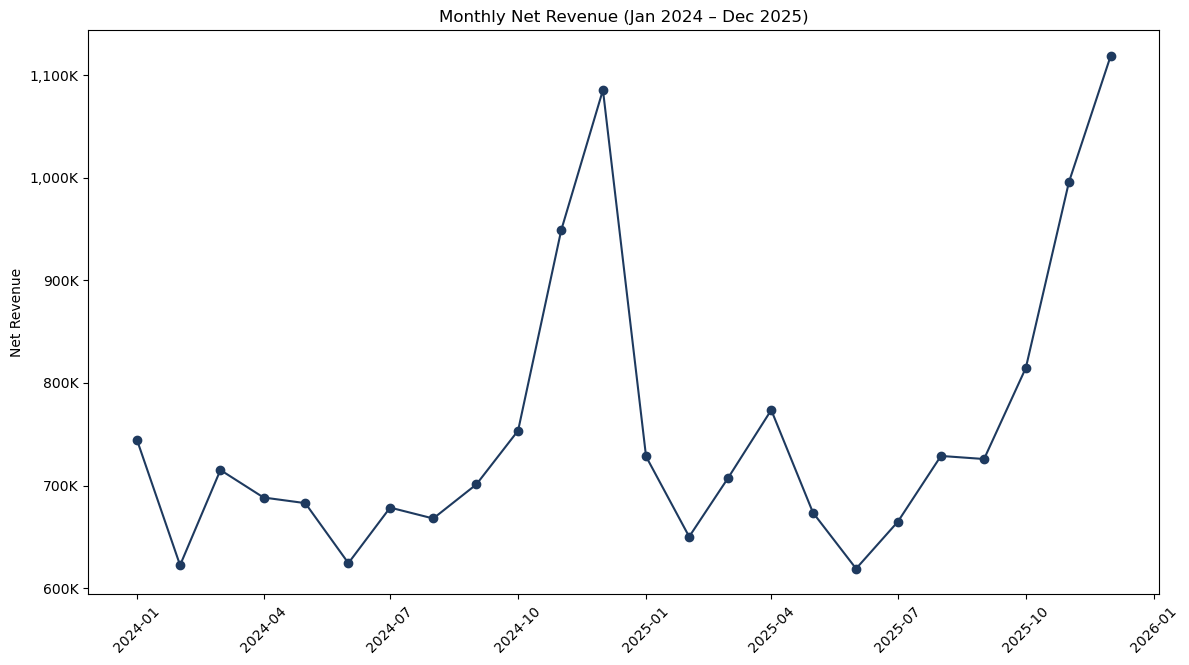

Saved ../exports/module5/monthly_revenue_trend.png


In [4]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color=NAVY)
ax.set_title('Monthly Net Revenue (Jan 2024 – Dec 2025)')
ax.set_ylabel('Net Revenue')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:,.0f}K'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
save_fig(fig, 'monthly_revenue_trend.png')

Revenue rises noticeably every November and
December in both years, then drops back in January — a clear, repeating
annual (12-month) seasonal pattern, on top of a mild overall upward trend.
This has two direct consequences for model choice:

- With only **24 months** of history, that is exactly **2 full seasonal
  cycles**. Several seasonal models (e.g. Holt-Winters' seasonal variant,
  SARIMA) need at least 2 full cycles just to *initialise* their seasonal
  component, and are still statistically fragile with only 2 — there is no
  spare data left to validate the seasonal estimate against. This is stated
  here explicitly as a limitation rather than glossed over.
- A simpler, more transparent approach — classical trend + seasonal-index
  decomposition — captures the same two features (trend, seasonality)
  without needing more data than is available, and is easier to explain to a
  business audience than a fitted ARIMA model.

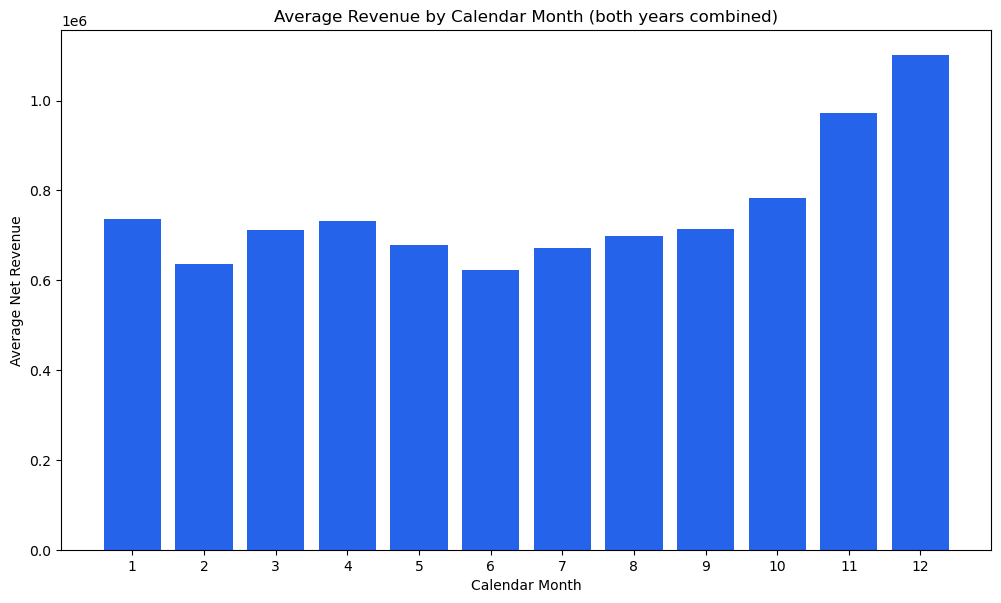

Saved ../exports/module5/seasonality_by_month.png


In [5]:
seasonal_check = monthly_revenue.groupby(monthly_revenue.index.month).mean()
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.bar(seasonal_check.index, seasonal_check.values, color=BLUE)
ax.set_xlabel('Calendar Month')
ax.set_ylabel('Average Net Revenue')
ax.set_title('Average Revenue by Calendar Month (both years combined)')
ax.set_xticks(range(1, 13))
plt.show()
save_fig(fig, 'seasonality_by_month.png')

## Train/Test Split & Naive Baseline

The last 3 months are held out as a test set and never touched
during model fitting. This gives an honest, out-of-sample check of forecast
accuracy.

**Naive baseline:** the simplest reasonable forecast — the average of the
last 3 training months, carried forward flat. Any real model needs to beat
this to be worth using.

In [6]:
HOLDOUT_MONTHS = 3
train = monthly_revenue.iloc[:-HOLDOUT_MONTHS]
test = monthly_revenue.iloc[-HOLDOUT_MONTHS:]
print(f"Train: {len(train)} months ({train.index[0].strftime('%Y-%m')} to {train.index[-1].strftime('%Y-%m')})")
print(f"Test:  {len(test)} months ({test.index[0].strftime('%Y-%m')} to {test.index[-1].strftime('%Y-%m')})")

naive_forecast = pd.Series([train.iloc[-3:].mean()] * HOLDOUT_MONTHS, index=test.index)
naive_forecast

Train: 21 months (2024-01 to 2025-09)
Test:  3 months (2025-10 to 2025-12)


transaction_date
2025-10-01   706,500.46
2025-11-01   706,500.46
2025-12-01   706,500.46
Freq: MS, dtype: float64

## Trend + Seasonal-Index Forecasting Model

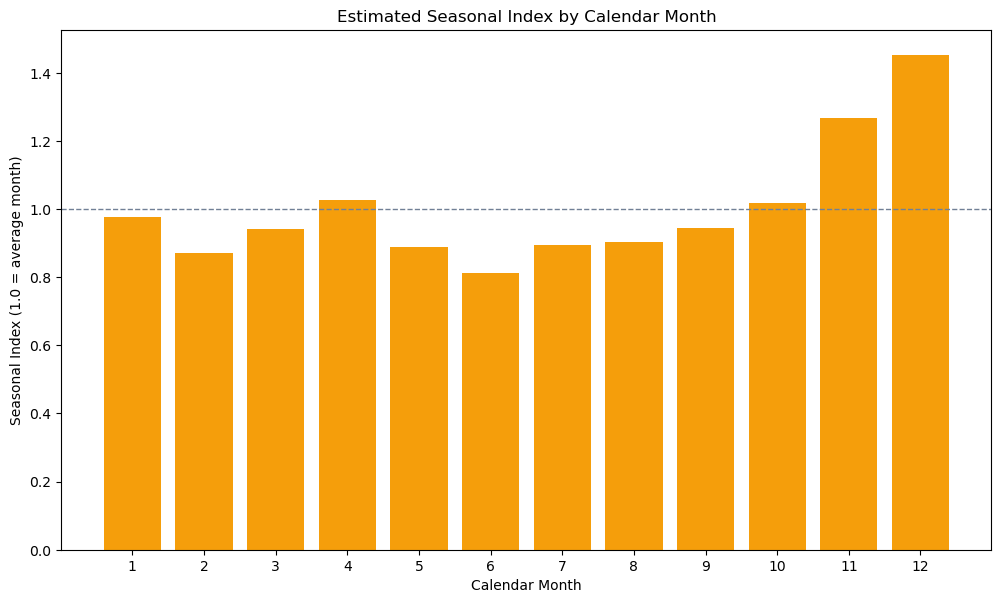

Saved ../exports/module5/seasonal_index.png


transaction_date
1    0.97
2    0.87
3    0.94
4    1.03
5    0.89
6    0.81
7    0.89
8    0.90
9    0.95
10   1.02
11   1.27
12   1.45
Name: net_revenue, dtype: float64

In [7]:
t = np.arange(len(monthly_revenue))

# Step 1: 12-month centered moving average = trend estimate
trend_ma = monthly_revenue.rolling(window=12, center=True).mean()

# Step 2: seasonal index per calendar month
ratio_to_trend = monthly_revenue / trend_ma
seasonal_index_raw = ratio_to_trend.groupby(monthly_revenue.index.month).mean()
seasonal_index = seasonal_index_raw / seasonal_index_raw.mean()  # normalise so the average index is 1.0

fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.bar(seasonal_index.index, seasonal_index.values, color=AMBER)
ax.axhline(1.0, color=SLATE, linestyle='--', linewidth=1)
ax.set_xlabel('Calendar Month')
ax.set_ylabel('Seasonal Index (1.0 = average month)')
ax.set_title('Estimated Seasonal Index by Calendar Month')
ax.set_xticks(range(1, 13))
plt.show()
save_fig(fig, 'seasonal_index.png')
seasonal_index.round(3)

In [8]:
# Step 3: deseasonalise, then fit a straight-line trend on the TRAINING portion only
deseasonalised = monthly_revenue / seasonal_index[monthly_revenue.index.month].values

train_len = len(train)
trend_coeffs = np.polyfit(t[:train_len], deseasonalised.values[:train_len], 1)
print(f"Fitted trend: revenue changes by about {trend_coeffs[0]:,.0f} per month (deseasonalised)")

Fitted trend: revenue changes by about 1,645 per month (deseasonalised)


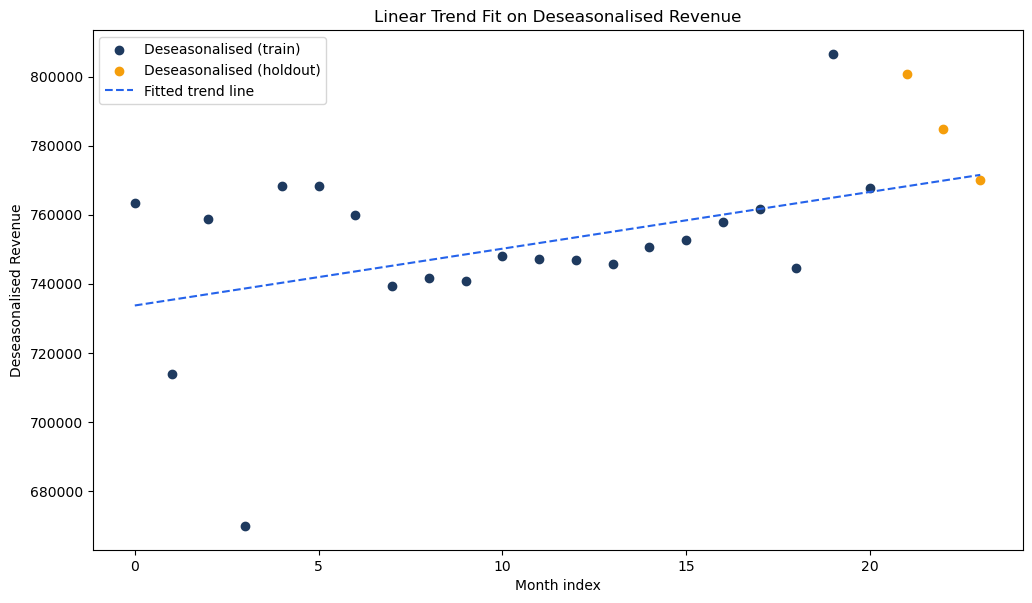

Saved ../exports/module5/trend_fit_deseasonalised.png


In [9]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.scatter(t[:train_len], deseasonalised.values[:train_len], color=NAVY, label='Deseasonalised (train)')
ax.scatter(t[train_len:], deseasonalised.values[train_len:], color=AMBER, label='Deseasonalised (holdout)')
ax.plot(t, np.polyval(trend_coeffs, t), color=BLUE, linestyle='--', label='Fitted trend line')
ax.set_xlabel('Month index')
ax.set_ylabel('Deseasonalised Revenue')
ax.set_title('Linear Trend Fit on Deseasonalised Revenue')
ax.legend()
plt.show()
save_fig(fig, 'trend_fit_deseasonalised.png')

In [10]:
# Step 4: forecast the test months by extending the trend line, then re-applying seasonality
forecast_t = t[train_len:train_len + HOLDOUT_MONTHS]
forecast_trend = np.polyval(trend_coeffs, forecast_t)
forecast_seasonal_idx = seasonal_index[monthly_revenue.index.month[train_len:train_len + HOLDOUT_MONTHS]].values
trend_seasonal_forecast = pd.Series(forecast_trend * forecast_seasonal_idx, index=test.index)
trend_seasonal_forecast

transaction_date
2025-10-01     781,361.46
2025-11-01     976,574.10
2025-12-01   1,120,823.06
Freq: MS, dtype: float64

## Forecast Accuracy on the Holdout Period

In [11]:
def mae(actual, pred):
    return np.mean(np.abs(actual - pred))

def rmse(actual, pred):
    return np.sqrt(np.mean((actual - pred) ** 2))

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

accuracy_results = []
for name, pred in [('Naive (flat average)', naive_forecast.values),
                    ('Trend + Seasonal Index', trend_seasonal_forecast.values)]:
    accuracy_results.append({
        'model': name,
        'MAE': round(mae(test.values, pred), 0),
        'RMSE': round(rmse(test.values, pred), 0),
        'MAPE (%)': round(mape(test.values, pred), 2),
    })

accuracy_df = pd.DataFrame(accuracy_results)
accuracy_df

,model,MAE,RMSE,MAPE (%)
0,Naive (flat average),"269,784.00","297,288.00",26.38
1,Trend + Seasonal Index,"18,167.00","22,150.00",2.06


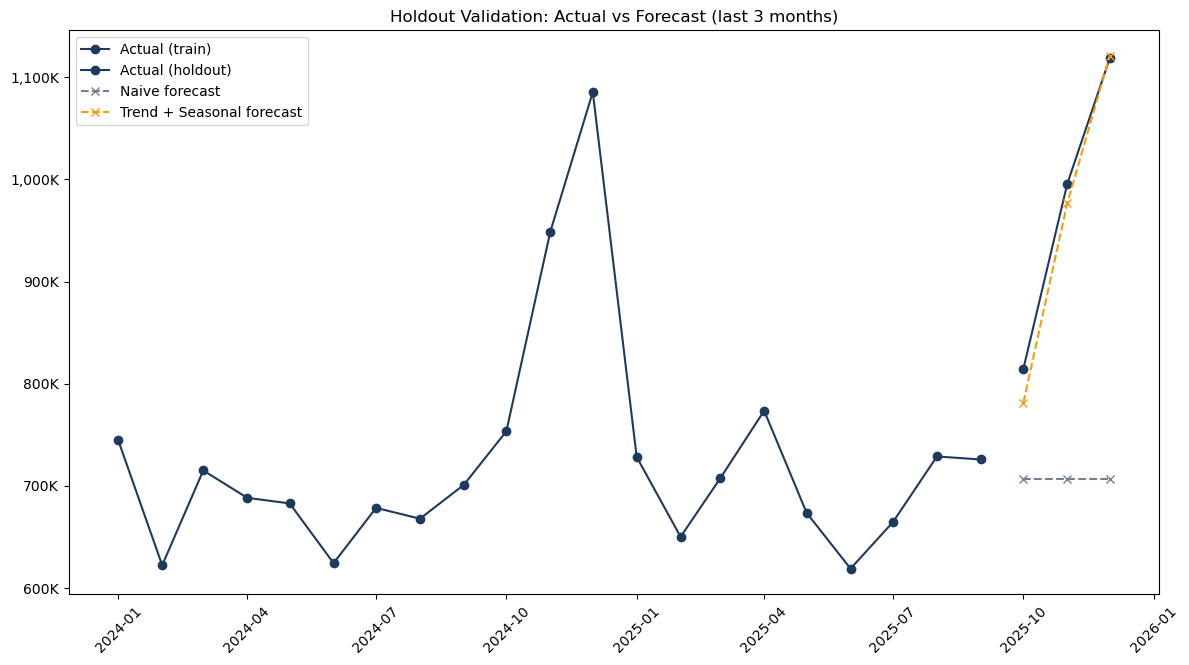

Saved ../exports/module5/holdout_validation.png


In [12]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.plot(train.index, train.values, marker='o', color=NAVY, label='Actual (train)')
ax.plot(test.index, test.values, marker='o', color=NAVY, linestyle='-', label='Actual (holdout)')
ax.plot(test.index, naive_forecast.values, marker='x', color=SLATE, linestyle='--', label='Naive forecast')
ax.plot(test.index, trend_seasonal_forecast.values, marker='x', color=AMBER, linestyle='--', label='Trend + Seasonal forecast')
ax.set_title('Holdout Validation: Actual vs Forecast (last 3 months)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:,.0f}K'))
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
save_fig(fig, 'holdout_validation.png')

* The trend + seasonal-index model has a much lower
MAPE than the naive baseline on data the model never saw during fitting —
confirming that explicitly modelling the November/December seasonal spike is
worth the extra step, rather than just assuming next month looks like the
recent average.

## Residual Diagnostics (Model Checking)

In [13]:
# Refit on the full series (all 24 months)
full_trend_coeffs = np.polyfit(t, deseasonalised.values, 1)
fitted_full = np.polyval(full_trend_coeffs, t) * seasonal_index[monthly_revenue.index.month].values
residuals = monthly_revenue.values - fitted_full

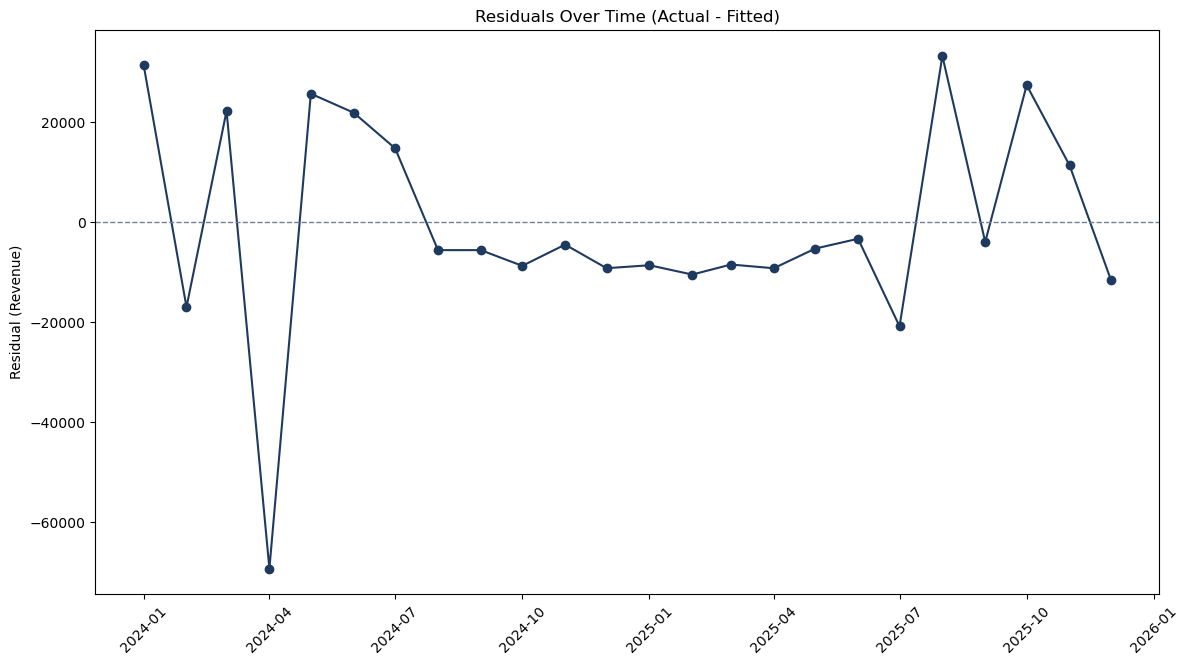

Saved ../exports/module5/residuals_over_time.png


In [14]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.plot(monthly_revenue.index, residuals, marker='o', color=NAVY)
ax.axhline(0, color=SLATE, linestyle='--', linewidth=1)
ax.set_title('Residuals Over Time (Actual - Fitted)')
ax.set_ylabel('Residual (Revenue)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
save_fig(fig, 'residuals_over_time.png')

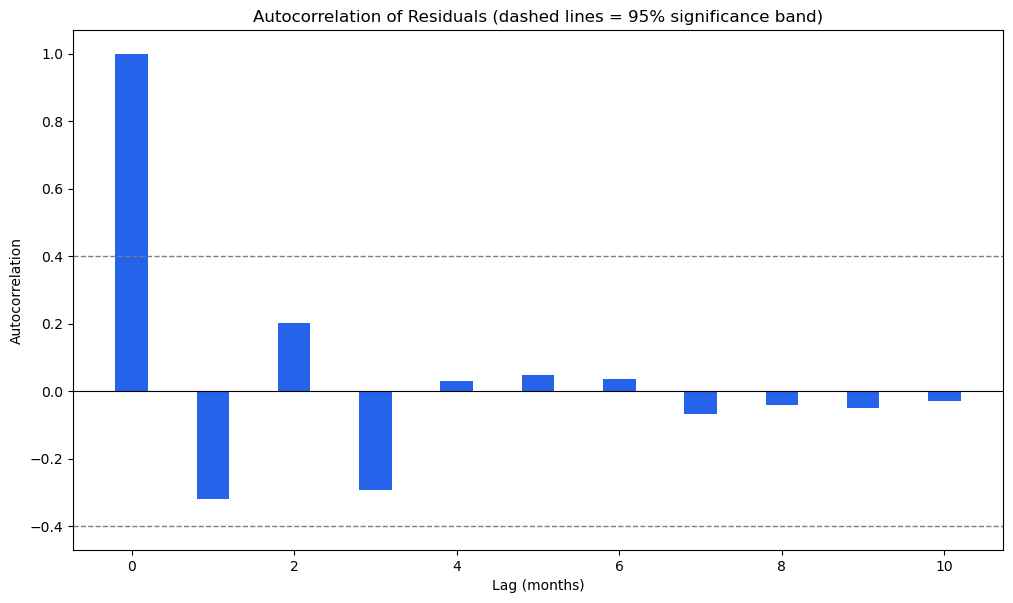

Saved ../exports/module5/residuals_acf.png


In [15]:
from statsmodels.tsa.stattools import acf

n = len(residuals)
n_lags = 10
acf_values = acf(residuals, nlags=n_lags, fft=False)
conf_band = 1.96 / np.sqrt(n)

fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.bar(range(n_lags + 1), acf_values, color=BLUE, width=0.4)
ax.axhline(conf_band, color=SLATE, linestyle='--', linewidth=1)
ax.axhline(-conf_band, color=SLATE, linestyle='--', linewidth=1)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Autocorrelation')
ax.set_title('Autocorrelation of Residuals (dashed lines = 95% significance band)')
plt.show()
save_fig(fig, 'residuals_acf.png')

Shapiro-Wilk test statistic: 0.861
Shapiro-Wilk p-value: 0.0036


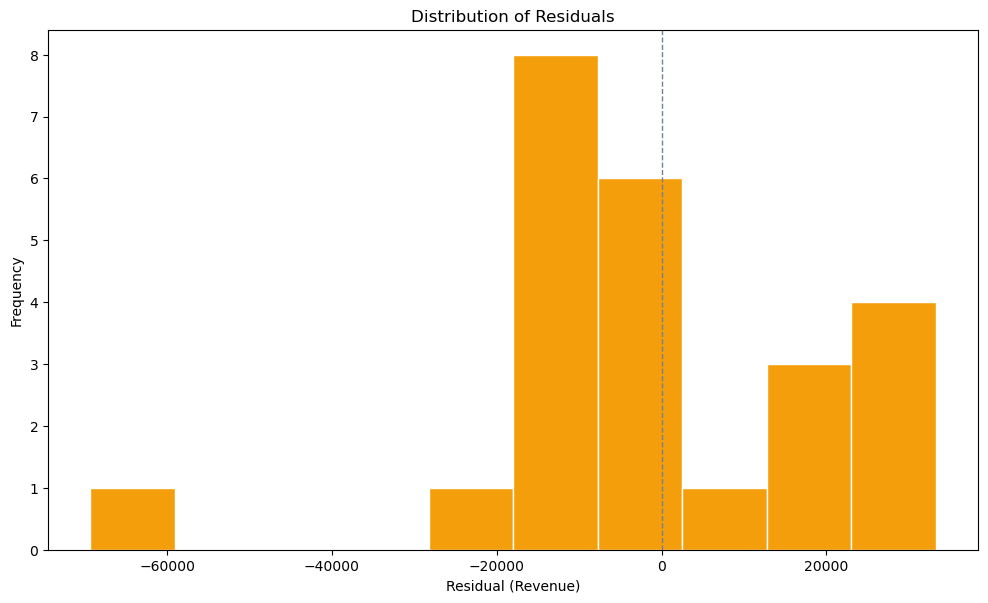

Saved ../exports/module5/residuals_histogram.png


In [16]:
from scipy import stats

shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk test statistic: {shapiro_stat:.3f}")
print(f"Shapiro-Wilk p-value: {shapiro_p:.4f}")

fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.hist(residuals, bins=10, color=AMBER, edgecolor='white')
ax.axvline(0, color=SLATE, linestyle='--', linewidth=1)
ax.set_xlabel('Residual (Revenue)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Residuals')
plt.show()
save_fig(fig, 'residuals_histogram.png')

First-half (2024) residual std:  26,117
Second-half (2025) residual std: 15,667
Levene's test statistic: 1.439
Levene's test p-value: 0.2431


C:\Users\META\AppData\Local\Temp\ipykernel_15868\1644051595.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([first_half, second_half], labels=['2024 residuals', '2025 residuals'])


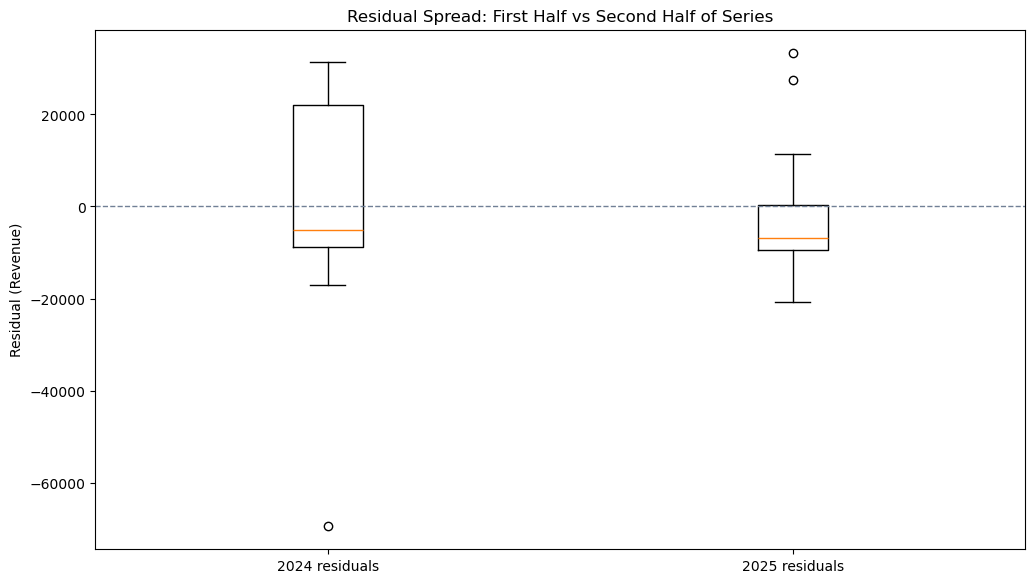

Saved ../exports/module5/residuals_homoscedasticity.png


In [17]:
# Split residuals into first half vs second half of the series and compare their spread
first_half = residuals[:12]
second_half = residuals[12:]

print(f"First-half (2024) residual std:  {first_half.std():,.0f}")
print(f"Second-half (2025) residual std: {second_half.std():,.0f}")

levene_stat, levene_p = stats.levene(first_half, second_half)
print(f"Levene's test statistic: {levene_stat:.3f}")
print(f"Levene's test p-value: {levene_p:.4f}")

fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.boxplot([first_half, second_half], labels=['2024 residuals', '2025 residuals'])
ax.axhline(0, color=SLATE, linestyle='--', linewidth=1)
ax.set_ylabel('Residual (Revenue)')
ax.set_title('Residual Spread: First Half vs Second Half of Series')
plt.show()
save_fig(fig, 'residuals_homoscedasticity.png')

In [18]:
diagnostics_summary = pd.DataFrame([
    {'Check': 'Residual pattern over time', 'Result': 'Larger errors in early 2024 (moving-average edge effect)', 'Verdict': 'Limitation noted'},
    {'Check': 'Autocorrelation (lag-1 ACF)', 'Result': f'{acf_values[1]:.3f}, within 95% band', 'Verdict': 'No significant issue (weak test power, n=24)'},
    {'Check': 'Normality (Shapiro-Wilk)', 'Result': f'p = {shapiro_p:.4f}', 'Verdict': 'Failed - residuals not normal'},
    {'Check': 'Homoscedasticity (Levene)', 'Result': f'p = {levene_p:.4f}', 'Verdict': 'Not significant, but visually uneven (n=12/group)'},
])
diagnostics_summary

,Check,Result,Verdict
0,Residual pattern over time,Larger errors in early 2024 (moving-average ed...,Limitation noted
1,Autocorrelation (lag-1 ACF),"-0.321, within 95% band","No significant issue (weak test power, n=24)"
2,Normality (Shapiro-Wilk),p = 0.0036,Failed - residuals not normal
3,Homoscedasticity (Levene),p = 0.2431,"Not significant, but visually uneven (n=12/group)"


## Final 6-Month Forecast with Scenario Bands

Refit the trend line on **all 24 months** (the holdout split was
only needed to validate the method — the final forecast should use every
available data point) and project 6 months ahead.

Rather than picking an arbitrary ± percentage, the
best/base/worst-case band width is set using the model's own in-sample
residual standard deviation (i.e. how far actual revenue typically deviated
from the fitted trend + seasonal line historically). This ties the scenario
range to the model's own demonstrated accuracy instead of a guessed number.

In [19]:
FORECAST_HORIZON = 6

future_t = np.arange(len(monthly_revenue), len(monthly_revenue) + FORECAST_HORIZON)
future_dates = [monthly_revenue.index[-1] + pd.DateOffset(months=i) for i in range(1, FORECAST_HORIZON + 1)]
future_months = [d.month for d in future_dates]

future_trend = np.polyval(full_trend_coeffs, future_t)
future_seasonal_idx = seasonal_index[future_months].values
base_forecast = future_trend * future_seasonal_idx

# Residual std from the full in-sample fit
residual_std = residuals.std()
print(f"In-sample residual std: {residual_std:,.0f} ({residual_std / monthly_revenue.mean() * 100:.1f}% of average monthly revenue)")

forecast_table = pd.DataFrame({
    'month': [d.strftime('%Y-%m') for d in future_dates],
    'worst_case': (base_forecast - residual_std).round(0),
    'base_case': base_forecast.round(0),
    'best_case': (base_forecast + residual_std).round(0),
})
forecast_table

In-sample residual std: 21,537 (2.9% of average monthly revenue)


,month,worst_case,base_case,best_case
0,2026-01,"739,228.00","760,765.00","782,302.00"
1,2026-02,"660,423.00","681,960.00","703,497.00"
2,2026-03,"717,404.00","738,941.00","760,478.00"
3,2026-04,"786,398.00","807,935.00","829,472.00"
4,2026-05,"679,057.00","700,594.00","722,131.00"
5,2026-06,"620,671.00","642,208.00","663,745.00"


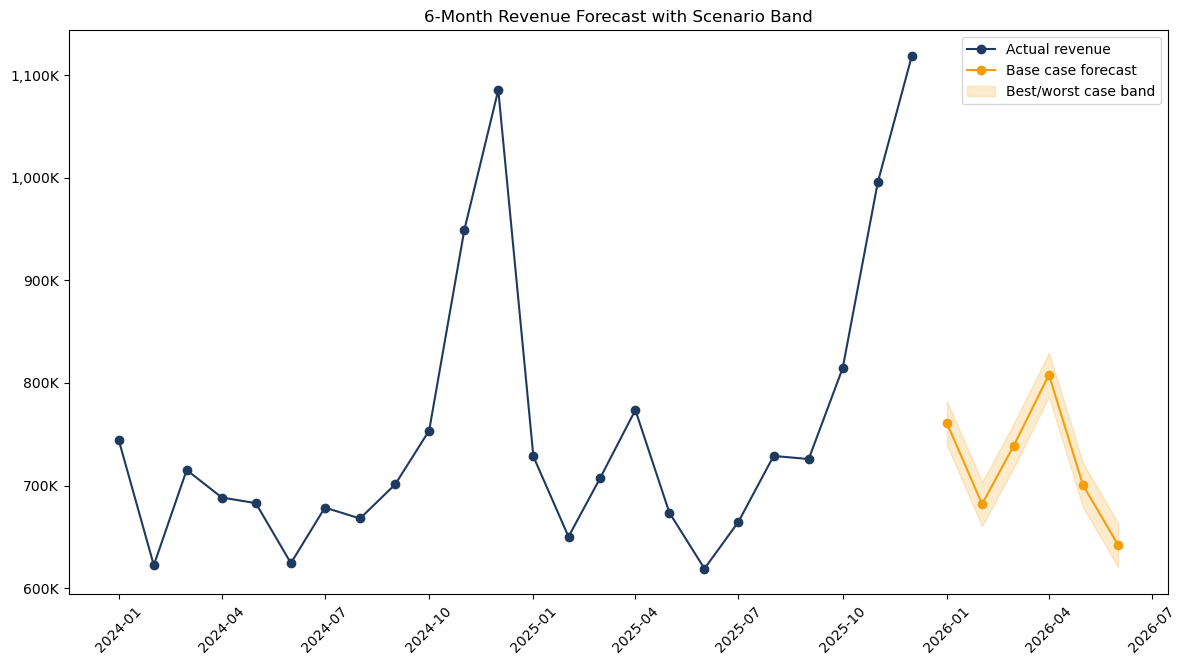

Saved ../exports/module5/final_forecast_scenarios.png


In [20]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color=NAVY, label='Actual revenue')
ax.plot(future_dates, base_forecast, marker='o', color=AMBER, label='Base case forecast')
ax.fill_between(future_dates, base_forecast - residual_std, base_forecast + residual_std,
                 color=AMBER, alpha=0.2, label='Best/worst case band')
ax.set_title(f'{FORECAST_HORIZON}-Month Revenue Forecast with Scenario Band')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:,.0f}K'))
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
save_fig(fig, 'final_forecast_scenarios.png')

In [21]:
summary_export = {
    'months_of_history': int(len(monthly_revenue)),
    'holdout_months': HOLDOUT_MONTHS,
    'accuracy_naive_mape': float(accuracy_df.loc[0, 'MAPE (%)']),
    'accuracy_trend_seasonal_mape': float(accuracy_df.loc[1, 'MAPE (%)']),
    'seasonal_index_by_month': seasonal_index.round(3).to_dict(),
    'residual_std': round(float(residual_std), 0),
    'forecast_horizon_months': FORECAST_HORIZON,
    'forecast_table': forecast_table.to_dict(orient='records'),
}
save_json(summary_export, 'module5_summary.json')
forecast_table.to_csv(f'{EXPORT_DIR}/revenue_forecast_next_6_months.csv', index=False)
print(f"Saved {EXPORT_DIR}/revenue_forecast_next_6_months.csv")

Saved ../exports/module5/module5_summary.json
Saved ../exports/module5/revenue_forecast_next_6_months.csv
